In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam



In [7]:
%connect_info

{"key":"8e22b087-ba4f-4bee-b742-fe5e0ed1fdd1","signature_scheme":"hmac-sha256","transport":"tcp","ip":"127.0.0.1","hb_port":9005,"control_port":9006,"shell_port":9007,"stdin_port":9008,"iopub_port":9009,"kernel_name":"python3115jvsc74a57bd0e51a11a35a9cffe10dbeeadb5683ca5855e70b329073972aeeab17b98f2e31e9"}

Paste the above JSON into a file, and connect with:
    $> jupyter <app> --existing <file>
or, if you are local, you can connect with just:
    $> jupyter <app> --existing c:\Users\Ngo_Duc_Phu\AppData\Roaming\jupyter\runtime\kernel-v302ee31b1bfdb5b597005c92745b6308eb32a898d.json
or even just:
    $> jupyter <app> --existing
if this is the most recent Jupyter kernel you have started.


Starting Grid Search...
Evaluating: Layers=1, Nodes=32, Activation=relu...


c:\Users\Ngo_Duc_Phu\Downloads\Python_code\Smart_distribution_project\SmartDistributionSystems\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Evaluating: Layers=1, Nodes=32, Activation=tanh...
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Evaluating: Layers=1, Nodes=32, Activation=sigmoid...
Evaluating: Layers=1, Nodes=32, Activation=linear...
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Evaluating: Layers=1, Nodes=64, Activation=relu...
Evaluating: Layers=1, Nodes=64, Activation=tanh...
Evaluating: Layers=1, Nodes=64, Activation=sigmoid...
Evaluating: Layers=1, Nodes=64, Activation=linear...
Evaluating: Layers=1, Nodes=128, Activation=relu...
Evaluating: Layers=1, Nodes=128, Activation=tanh...
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Evaluating: Layers=1, Nodes=128, Activation=sigmoid...
Evaluating: Layers=1, Nodes=128, Activation=linear...
Evaluating: Layers=2, Nodes=32, Activation=relu...
Evaluating: Layers=2, Nodes=32, Activation=tanh...
Evaluating: Layers=2, Nodes=32, Activation=sigmoid...
Evaluating: Layers=2, Nodes=32, Activation=linear...
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Evaluating: Layers=2,

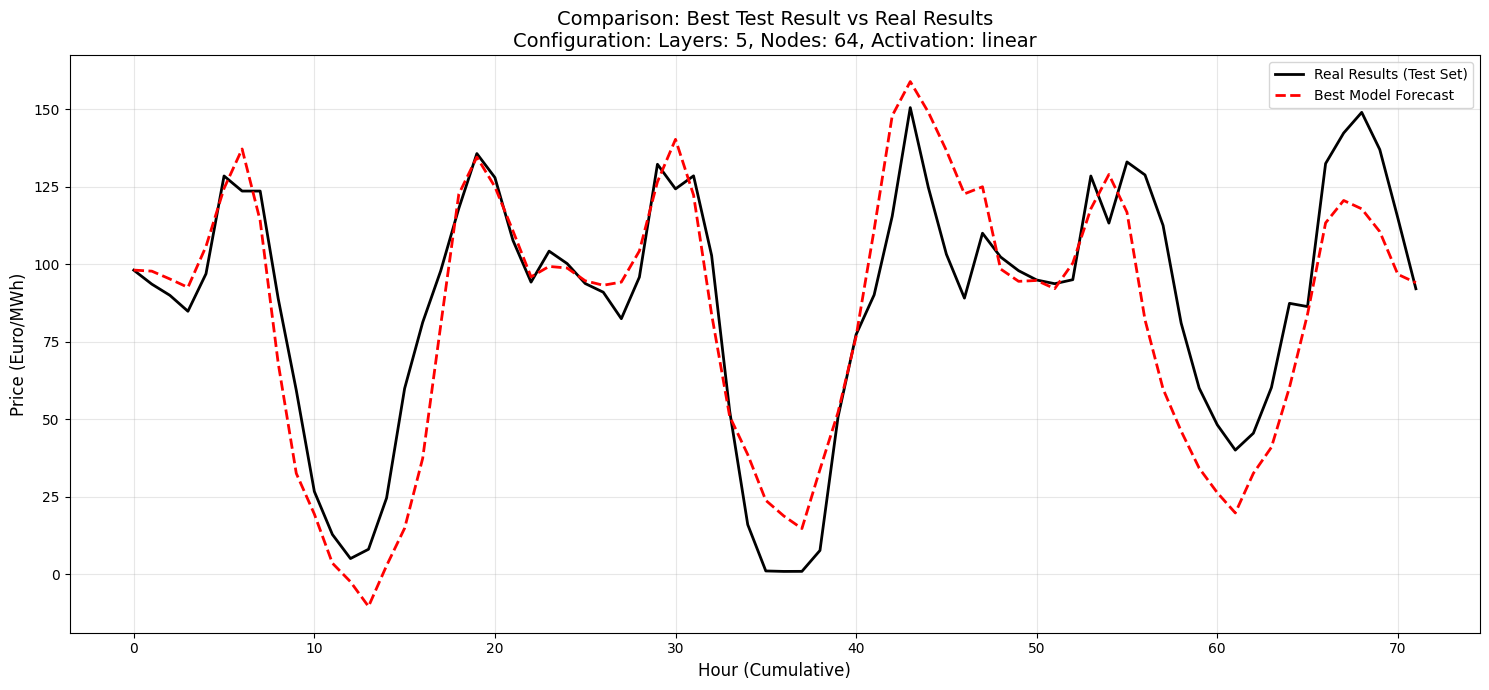

In [6]:
# ==========================================
# 1. DATA PREPARATION
# ==========================================
df_all = pd.read_csv('Full_Dataset.csv', header=0)
df_all.rename(columns={'Date': 'time'}, inplace=True)
df_all['time'] = pd.to_datetime(df_all['time'], dayfirst=True)
df_all.set_index('time', inplace=True)

df_all = df_all.groupby(level=0).mean()
data = df_all[['Price_BE', 'Solar_BE', 'Wind_BE', 'Load_BE']].resample('1h').mean().ffill()
data.columns = ['belpex', 'solar', 'wind', 'load']

price, solar, wind, load = data.belpex.values, data.solar.values, data.wind.values, data.load.values
n_hours = 24
X_list, Y_list = [], []
days = len(data) // n_hours

for d in range(7, days):
    y_day = price[d*24 : (d+1)*24]
    features = np.concatenate([
        price[(d-1)*24 : d*24], 
        price[(d-7)*24 : (d-6)*24], 
        solar[d*24 : (d+1)*24], 
        wind[d*24 : (d+1)*24], 
        load[d*24 : (d+1)*24]
    ])
    X_list.append(features)
    Y_list.append(y_day)

X, Y = np.array(X_list), np.array(Y_list)

# Scaling
scaler_x, scaler_y = StandardScaler(), StandardScaler()
X_scaled = scaler_x.fit_transform(X)
Y_scaled = scaler_y.fit_transform(Y)

# CORRECTED SPLITTING LOGIC
# First split: Separate the test set (15%)
X_train_val, X_test, Y_train_val, Y_test = train_test_split(X_scaled, Y_scaled, test_size=0.15, shuffle=False)
# Second split: Separate training (70%) and validation (15%)
X_train, X_val, Y_train, Y_val = train_test_split(X_train_val, Y_train_val, test_size=0.176, shuffle=False)

# ==========================================
# 2. GRID SEARCH
# ==========================================
layer_options = [1, 2, 3, 4, 5]
node_options = [32, 64, 128]
activation_options = ['relu', 'tanh', 'sigmoid', 'linear'] # Linear, Non-linear, and Sigmoid

results_list = []
best_test_mse = float('inf')
best_predictions = None
best_config = ""

print("Starting Grid Search...")
for layers in layer_options:
    for nodes in node_options:
        for act in activation_options:
            print(f"Evaluating: Layers={layers}, Nodes={nodes}, Activation={act}...")
            
            model = Sequential()
            model.add(Dense(nodes, input_dim=X_train.shape[1], activation=act))
            for _ in range(layers - 1):
                model.add(Dense(nodes, activation=act))
            model.add(Dense(24, activation='linear')) # Output layer for prices
            
            model.compile(loss='mse', optimizer=Adam(learning_rate=0.001))
            model.fit(X_train, Y_train, epochs=50, batch_size=32, verbose=0)
            
            # Record MSEs
            train_mse = model.evaluate(X_train, Y_train, verbose=0)
            val_mse = model.evaluate(X_val, Y_val, verbose=0)
            test_mse = model.evaluate(X_test, Y_test, verbose=0)
            
            results_list.append({
                'Layers': layers, 'Nodes': nodes, 'Activation': act,
                'Train_MSE': round(train_mse, 5), 
                'Val_MSE': round(val_mse, 5), 
                'Test_MSE': round(test_mse, 5)
            })
            
            if test_mse < best_test_mse:
                best_test_mse = test_mse
                best_predictions = model.predict(X_test)
                best_config = f"Layers: {layers}, Nodes: {nodes}, Activation: {act}"

# ==========================================
# 3. RESULTS TABLE & PLOT
# ==========================================
comparison_df = pd.DataFrame(results_list).sort_values(by='Test_MSE')
print("\n--- Model Comparison Table ---")
print(comparison_df.to_string(index=False))

# Prepare data for plotting
final_preds = scaler_y.inverse_transform(best_predictions)
final_actuals = scaler_y.inverse_transform(Y_test)

plt.figure(figsize=(15, 7))
plt.plot(final_actuals[:3].flatten(), label='Real Results (Test Set)', color='black', linewidth=2)
plt.plot(final_preds[:3].flatten(), label='Best Model Forecast', color='red', linestyle='--', linewidth=2)

plt.title(f'Comparison: Best Test Result vs Real Results\nConfiguration: {best_config}', fontsize=14)
plt.xlabel('Hour (Cumulative)', fontsize=12)
plt.ylabel('Price (Euro/MWh)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
#Seem like the best ANN architecture to use is 5 layers, 64 nodes, Linear activation

model_2 = Sequential()
nodes = 64
act = 'linear'
model_2.add(Dense(nodes, input_dim=X_train.shape[1], activation=act))
for _ in range(layers - 1):
    model_2.add(Dense(nodes, activation=act))
model_2.add(Dense(24, activation='linear')) # Output layer for prices

model_2.compile(loss='mse', optimizer=Adam(learning_rate=0.001))
model_2.fit(X_train, Y_train, epochs=100, batch_size=32, verbose=1)

Epoch 1/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6157
Epoch 2/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1687 
Epoch 3/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1367 
Epoch 4/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1282 
Epoch 5/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1222 
Epoch 6/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1308 
Epoch 7/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1216 
Epoch 8/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1244 
Epoch 9/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1161
Epoch 10/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1104 
Epoch 11/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1133 
Epoch 12/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1104 
Epoch 13/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1097 
Epoch 14/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1114 
Epoch 15/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss:

In [16]:
#Keep learning with finer learning rate
model_2.optimizer.learning_rate = 0.0000001
model_2.fit(X_train, Y_train, epochs=100, batch_size=12, verbose=1)

Epoch 1/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0871
Epoch 2/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0870
Epoch 3/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0871
Epoch 4/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0870
Epoch 5/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0870
Epoch 6/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0870
Epoch 7/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0870
Epoch 8/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0870
Epoch 9/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0870
Epoch 10/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0870
Epoch 11/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0870
Epoch 12/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0870
Epoch 13/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0870
Epoch 14/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0870
Epoch 15/100
110/110 ━━━━━━━━━━━━━━━━━━━━ 0

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
train_MSE:  0.08704123646020889
val_MSE:  0.21122589707374573
test_MSE:  0.05071336030960083


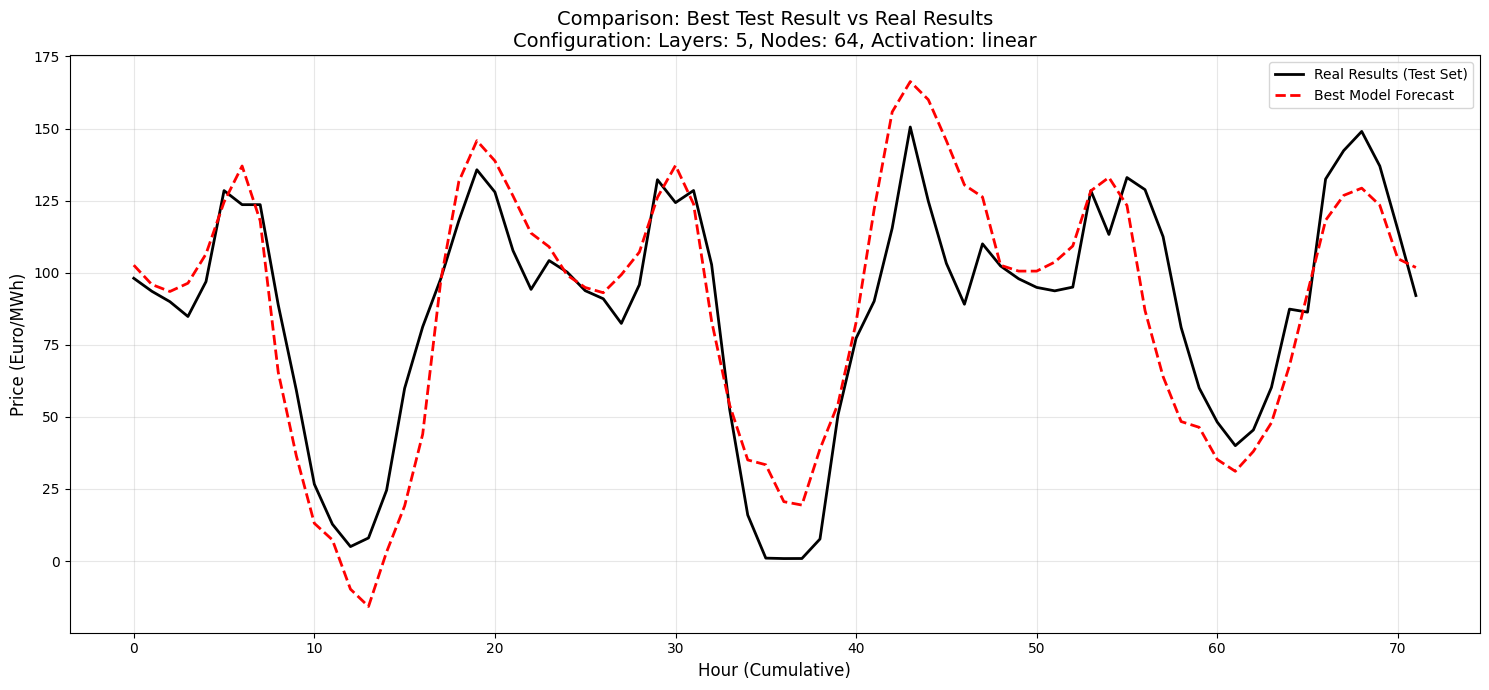

In [26]:
#Model evaluations
# Record MSEs
train_mse = model_2.evaluate(X_train, Y_train, verbose=0)
val_mse = model_2.evaluate(X_val, Y_val, verbose=0)
test_mse = model_2.evaluate(X_test, Y_test, verbose=0)
best_predictions = model_2.predict(X_test)
# results_list.append({
#     'Layers': layers, 'Nodes': nodes, 'Activation': act,
#     'Train_MSE': round(train_mse, 5), 
#     'Val_MSE': round(val_mse, 5), 
#     'Test_MSE': round(test_mse, 5)
# })

# if test_mse < best_test_mse:
#     best_test_mse = test_mse
#     best_predictions = model.predict(X_test)
#     best_config = f"Layers: {layers}, Nodes: {nodes}, Activation: {act}"

# comparison_df = pd.DataFrame(results_list).sort_values(by='Test_MSE')
# print("\n--- Model Comparison Table ---")
# print(comparison_df.to_string(index=False))
print("train_MSE: ", train_mse)
print("val_MSE: ", val_mse)
print("test_MSE: ", test_mse)

# Prepare data for plotting
final_preds = scaler_y.inverse_transform(best_predictions)
final_actuals = scaler_y.inverse_transform(Y_test)

plt.figure(figsize=(15, 7))
plt.plot(final_actuals[:3].flatten(), label='Real Results (Test Set)', color='black', linewidth=2)
plt.plot(final_preds[:3].flatten(), label='Best Model Forecast', color='red', linestyle='--', linewidth=2)

plt.title(f'Comparison: Best Test Result vs Real Results\nConfiguration: {best_config}', fontsize=14)
plt.xlabel('Hour (Cumulative)', fontsize=12)
plt.ylabel('Price (Euro/MWh)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
#Save model 2 for later use and comparison
model_2.save('./trained_model/model_2.keras')

In [20]:
#How to load the model from saved ones
from tensorflow.keras.models import load_model
model_2_loaded = load_model('./trained_model/model_2.keras')
model_2_loaded.summary()

Model: "sequential_77"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_286 (Dense)               │ (None, 64)             │         7,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_287 (Dense)               │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_288 (Dense)               │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_289 (Dense)               │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_290 (Dense)               │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_291 (Dense)               │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,834 (304.04 KB)

 Trainable params: 25,944 (101.34 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 51,890 (202.70 KB)